# Nestorowa Hematopoiesis — Visual Method Comparison

Qualitative and quantitative comparison of manifold-learning methods on the Nestorowa et al.\ (2016) mouse hematopoietic stem and progenitor cell scRNA-seq dataset \citep{nestorowa2016hematopoiesis}, a standard benchmark used by PHATE \citep{moon2019phate}, DTNE \citep{wei2025dtne}, and Palantir \citep{setty2019palantir}.

The dataset captures **multi-lineage commitment from hematopoietic stem cells**: HSPCs branch through lymphoid-primed (LMPP) and myeloid-erythroid intermediates toward erythroid (MEP/Ery), granulocyte-monocyte (GMP), and lymphoid lineages. The branching topology resembles our synthetic tree benchmarks, and ground-truth cell-type annotations come from flow-cytometry sorting at the time of sequencing.

Cell-type labels are derived from observation-name prefixes (e.g.\ `HSPC_001` → `HSPC`), which encode the FACS sorting gate. Because these gates correspond to overlapping progenitor states along a continuous developmental landscape rather than discrete clusters, this is a **trajectory dataset**: following the convention of DTNE and PHATE, pseudotime correlation and embedding quality are the primary evaluation criteria, with DEMaP and trustworthiness as supporting distance-fidelity measures. ARI/NMI are reported for completeness but interpreted with caution, since clustering metrics are ill-posed on a continuous progenitor landscape with overlapping FACS gates.

## Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

# Method classes
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import phate
from entropath import EntroPath
from heatgeo.embedding import HeatGeo
from dtne import DTNE

from utils.bio_utils import (
    get_bio_methods, run_methods, compute_bio_metrics,
    plot_embedding_row, plot_embedding_grid,
    plot_pseudotime_panels, plot_pseudotime_boxplot,
    save_bio_artifacts, save_metrics_csv,
    geodesic_from_root, correlation_triple,
    BIO_PLOT_ORDER,
)
from entropath import EntroPath

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

## Configuration

`K_NN = 15` matches the cross-dataset default for the bio suite and DTNE's Nestorowa configuration \citep{wei2025dtne}. EntroPath hyperparameters use the package defaults (no landmarks, `smacof` MDS, automatic `t_power` selection) since Nestorowa is small (~1656 cells) and the full-rank path is fast.

In [2]:
SEED          = 42
K_NN          = 15

# Pseudotime root — HSPC cell index 657 (matches DTNE notebook)
ROOT_CELL_IDX = 657

# Output paths
RESULTS_DIR = PROJECT_ROOT / "results" / "nestorowa"
FIGURES_DIR = PROJECT_ROOT / "figures" / "nestorowa"
DATA_DIR    = PROJECT_ROOT / "data"    / "nestorowa"
for d in (RESULTS_DIR, FIGURES_DIR, DATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Random seed:  {SEED}")
print(f"k_nn:         {K_NN}")
print(f"Root cell:    {ROOT_CELL_IDX}")
print(f"Results dir:  {RESULTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures dir:  {FIGURES_DIR.relative_to(PROJECT_ROOT)}")

Random seed:  42
k_nn:         15
Root cell:    657
Results dir:  results/nestorowa
Figures dir:  figures/nestorowa


## Load Nestorowa dataset

The DTNE-provided `nestorowa.data2.h5ad` contains ~1656 cells with `X_pca` precomputed (30 components) and integer `cell_label` codes. Available from the DTNE Google Drive folder linked in the repository's README.

In [3]:
CACHE_PATH = DATA_DIR / "nestorowa.data2.h5ad"

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Place nestorowa.data2.h5ad in {DATA_DIR}. "
        "Available from the DTNE Google Drive: "
        "https://drive.google.com/drive/folders/1UFKBWFJ7BhzcABpa4DZXssthQuTGMfmU"
    )

adata = sc.read_h5ad(CACHE_PATH)
print(f"Loaded {CACHE_PATH.name}")
print(f"\nShape:     {adata.shape}")
print(f"obs keys:  {list(adata.obs.columns)}")
print(f"obsm keys: {list(adata.obsm.keys())}")

Loaded nestorowa.data2.h5ad

Shape:     (1656, 46078)
obs keys:  ['cell_label']
obsm keys: ['X_pca']


In [4]:
print(adata)
print('cell_label values:', sorted(set(adata.obs['cell_label'])))
print('counts:\n', adata.obs['cell_label'].value_counts())
# also check what X_pca they ship
print('X_pca shape:', adata.obsm['X_pca'].shape)

AnnData object with n_obs × n_vars = 1656 × 46078
    obs: 'cell_label'
    uns: 'iroot'
    obsm: 'X_pca'
cell_label values: [1, 2, 3, 4, 5, 6, 7, 8, 9]
counts:
 cell_label
2    472
3    258
6    229
1    203
4    175
5    142
8     83
9     74
7     20
Name: count, dtype: int64
X_pca shape: (1656, 9)


In [5]:
# Use DTNE's PCA representation (their nestorowa.data2.h5ad ships 9-component X_pca)
if "X_pca" in adata.obsm:
    X = adata.obsm["X_pca"]
    print(f"Using X_pca: shape {X.shape}")
else:
    print("X_pca not in adata.obsm — computing PCA on raw expression")
    sc.pp.pca(adata, n_comps=30)
    X = adata.obsm["X_pca"]
    print(f"Computed X_pca: shape {X.shape}")

# Cell-type labels: use DTNE's 9-class `cell_label` (from nestorowa.data2.h5ad)
# to match their benchmark exactly. These are finer than the 3 broad FACS gates
# (HSPC/LT-HSC/Prog) encoded in the observation-name prefixes.
if "cell_label" in adata.obs:
    cell_types_str = adata.obs["cell_label"].astype(str).values
    print(f"Using DTNE 'cell_label': {len(set(cell_types_str))} classes")
else:
    # Fallback: derive broad gates from observation names ("HSPC_001" -> "HSPC")
    cell_types_str = np.array(
        [re.match(r"([^_]+)", n).group(1) for n in adata.obs_names]
    )
    print(f"'cell_label' absent — derived {len(set(cell_types_str))} labels from obs_names.")

# Order categories numerically if they're integer-like, else alphabetically
try:
    cats = sorted(set(cell_types_str), key=lambda x: int(x))
except ValueError:
    cats = sorted(set(cell_types_str))
adata.obs["cell_type"] = pd.Categorical(cell_types_str, categories=cats)

# Labels and palette
labels       = adata.obs["cell_type"].values
label_codes  = adata.obs["cell_type"].cat.codes.values
categories   = list(adata.obs["cell_type"].cat.categories)
n_clusters   = len(categories)

# Categorical palette — 9 classes need tab10 (distinct hues)
base_cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20")
palette_list = [base_cmap(i % base_cmap.N) for i in range(n_clusters)]
zip_types   = dict(zip(categories, palette_list))
cell_colors = [zip_types[l] for l in labels]

# Root cell: use DTNE's canonical iroot if present
if "iroot" in adata.uns:
    ROOT_CELL_IDX = int(adata.uns["iroot"])
    print(f"Using DTNE canonical root: iroot={ROOT_CELL_IDX}")
root_label = labels[ROOT_CELL_IDX]

print(f"\nCell types ({n_clusters}):")
for cat in categories:
    n = int((labels == cat).sum())
    print(f"  {cat:>20s}: {n} cells")
print(f"\nRoot cell: idx={ROOT_CELL_IDX} (label={root_label})")

Using X_pca: shape (1656, 9)
Using DTNE 'cell_label': 9 classes
Using DTNE canonical root: iroot=657

Cell types (9):
                     1: 203 cells
                     2: 472 cells
                     3: 258 cells
                     4: 175 cells
                     5: 142 cells
                     6: 229 cells
                     7: 20 cells
                     8: 83 cells
                     9: 74 cells

Root cell: idx=657 (label=8)


## Run all methods

Nestorowa is small (~1656 cells), so all methods run in seconds and EntroPath uses its full-rank path (no landmarks).

In [6]:
#methods = get_bio_methods(SEED, k_nn=K_NN)

methods = {
    "PCA":       PCA(n_components=2),
    "t-SNE":     TSNE(perplexity=30, random_state=SEED),
    "UMAP":      UMAP(min_dist=0.5, random_state=SEED),
    "PHATE":     phate.PHATE(knn=10, random_state=SEED, verbose=False),
    "HeatGeo":   HeatGeo(knn=5),
    "DTNE":      DTNE(k_neighbors=15),
    "EntroPath": EntroPath(k_neighbors=15, kernel="alpha_decay", mds_solver="smacof",
                           landmarks_method="kmeans", random_state=SEED, verbose=False),
}

print(f"Methods: {list(methods.keys())}\n")

embeddings, runtimes = run_methods(methods, X)

Methods: ['PCA', 't-SNE', 'UMAP', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']

  PCA                done (   0.0s)
  t-SNE              done (   3.1s)
  UMAP               

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


done (   6.9s)
  PHATE                  SGD-MDS may not have converged: stress changed by 1.7% in final iterations. Consider increasing n_iter or adjusting learning_rate.
done (   2.4s)
  HeatGeo            Using s_gd2 for MDS. None
done (   1.4s)
  DTNE               done (   1.9s)
  EntroPath          done (   4.0s)  (t_power = 20)

=== Done — 7/7 methods succeeded ===


## Quantitative metrics

ARI / NMI from Agglomerative clustering on each embedding (interpreted with caution given FACS-gate overlap on Nestorowa), trustworthiness against the high-dimensional PCA representation, and DTNE-style subsampled DEMaP \citep{wei2025dtne} as the primary geodesic-fidelity metric.

In [7]:
df_nestorowa = compute_bio_metrics(
    embeddings, X,
    label_codes=label_codes,
    n_clusters=n_clusters,
    demap_n_subsample=500,
    runtimes=runtimes,
    plot_order=BIO_PLOT_ORDER,
    random_state=SEED,
)

print()
print(df_nestorowa.round(3).to_string())
print()
print("=== LaTeX ===")
print(df_nestorowa.round(3).to_latex(escape=False, float_format="%.3f"))

Computing bio metrics:
  DEMaP: n_subsample=500, n_repeats=50, knn=50
  Trustworthiness/Continuity: k=15
  X_input == X_ref (single reference, shape (1656, 9))

  PCA                DEMaP = 0.925 ± 0.008, T = 0.913, C = 0.966
  t-SNE              DEMaP = 0.906 ± 0.006, T = 0.985, C = 0.972
  UMAP               DEMaP = 0.919 ± 0.005, T = 0.963, C = 0.980
  PHATE              DEMaP = 0.890 ± 0.006, T = 0.933, C = 0.973
  HeatGeo            DEMaP = 0.862 ± 0.008, T = 0.932, C = 0.969
  DTNE               DEMaP = 0.906 ± 0.005, T = 0.930, C = 0.974
  EntroPath          DEMaP = 0.908 ± 0.007, T = 0.946, C = 0.970

           DEMaP (mean)  DEMaP (std)    ARI    NMI  Trustworthiness  Continuity  Runtime (s)
Method                                                                                      
PCA               0.925        0.008  0.533  0.640            0.913       0.966        0.001
t-SNE             0.906        0.006  0.693  0.780            0.985       0.972        3.058
UMAP       

## Plots

### Embedding row — primary figure

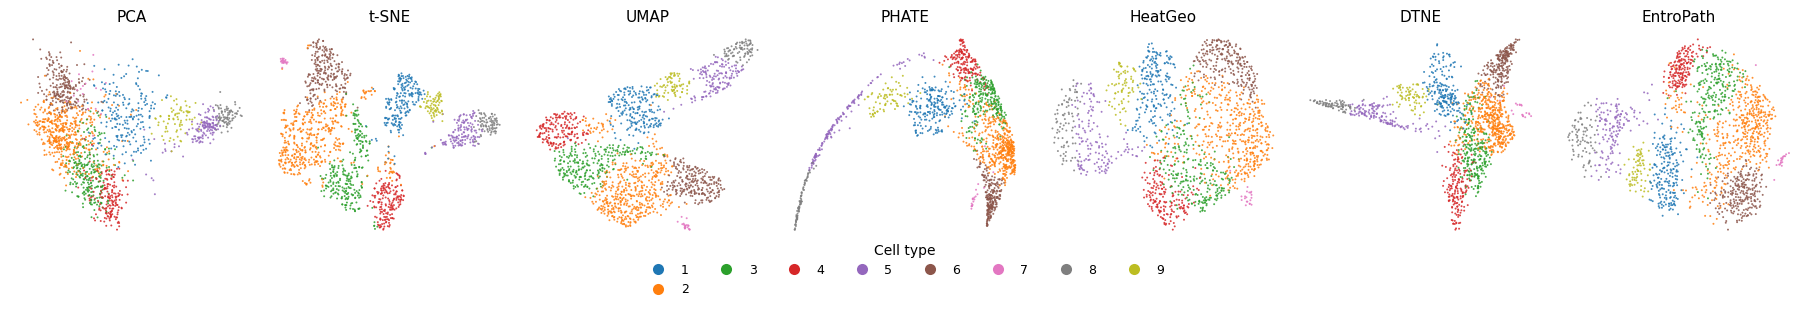

(<Figure size 1820x295 with 7 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'HeatGeo'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>], dtype=object))

In [8]:
plot_embedding_row(
    embeddings, BIO_PLOT_ORDER, cell_colors, zip_types,
    runtimes=None,
    save_path=FIGURES_DIR / "nestorowa_row",
)

### Embedding grid (alternative layout)

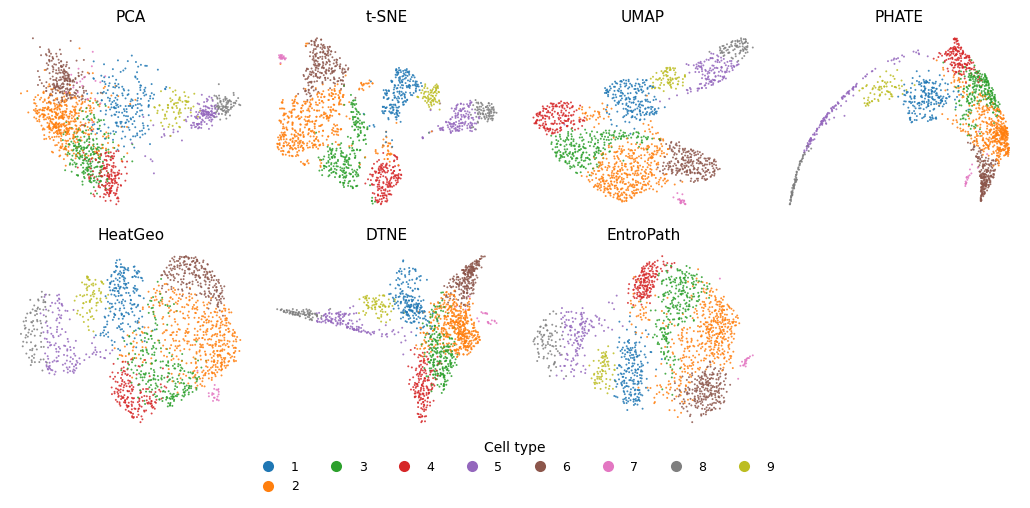

(<Figure size 1040x490 with 8 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'HeatGeo'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>, <Axes: >], dtype=object))

In [9]:
plot_embedding_grid(
    embeddings, BIO_PLOT_ORDER, cell_colors, zip_types,
    runtimes=None,
    save_path=FIGURES_DIR / "nestorowa_grid",
)

## Save artifacts

In [10]:
artifact_path = save_bio_artifacts(
    embeddings, runtimes, labels, label_codes, zip_types,
    X_shape=X.shape,
    config={
        "seed":      SEED,
        "k_nn":      K_NN,
        "root_cell": ROOT_CELL_IDX,
    },
    results_dir=RESULTS_DIR,
    basename="nestorowa",
)
metrics_path = save_metrics_csv(df_nestorowa, RESULTS_DIR, "nestorowa")

print(f"Embeddings saved to {artifact_path.relative_to(PROJECT_ROOT)}")
print(f"Metrics saved to    {metrics_path.relative_to(PROJECT_ROOT)}")

Embeddings saved to results/nestorowa/nestorowa_embeddings.pkl
Metrics saved to    results/nestorowa/nestorowa_metrics.csv


## EntroPath downstream analysis (optional)

Pseudotime ordering and pseudotime-based clustering are integrated EntroPath features, separate from the comparison table above (which uses the same Agglomerative clustering for all methods to ensure fairness).

Root cell is index 657 (an HSPC, matching the DTNE notebook). The geodesic-pseudotime correlation below compares each method's pseudotime against the high-D geodesic distance from this root — a well-ordered embedding places HSPCs at lowest pseudotime and committed/terminal states (Prog, erythroid- and lymphoid-primed) at highest.

Root cell 657: type = 8


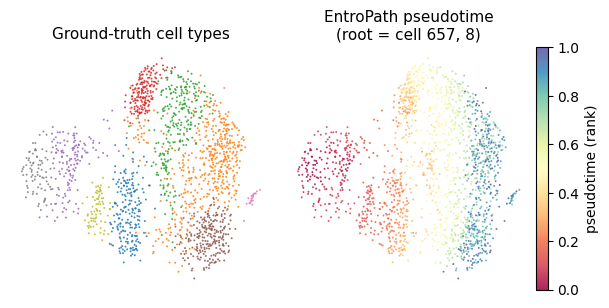


Pseudotime range: [0.000, 1.000]


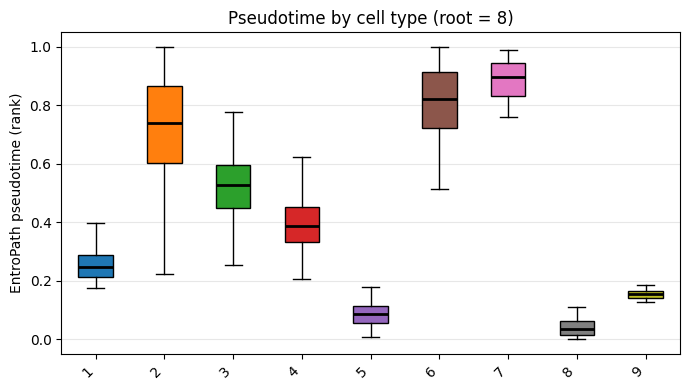

In [11]:
RUN_ENTROPATH_DOWNSTREAM = True

if RUN_ENTROPATH_DOWNSTREAM and "EntroPath" in embeddings:
    pseudotime = plot_pseudotime_panels(
        methods["EntroPath"], "EntroPath",
        embeddings["EntroPath"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types,
        save_path=FIGURES_DIR / "nestorowa_entropath_pseudotime",
    )
    if pseudotime is not None:
        adata.obs["pseudotime_entropath"] = pseudotime
        print(f"\nPseudotime range: [{pseudotime.min():.3f}, {pseudotime.max():.3f}]")
        plot_pseudotime_boxplot(
            pseudotime, labels,
            adata.obs["cell_type"].cat.categories,    # ← cell_type, not nestorowa_clusters
            zip_types,
            method_name="EntroPath",
            root_label=labels[ROOT_CELL_IDX],
            save_path=FIGURES_DIR / "nestorowa_pseudotime_by_type",
        )
elif RUN_ENTROPATH_DOWNSTREAM:
    print("EntroPath embedding not available — skipping downstream.")
else:
    print("Pseudotime skipped (set RUN_ENTROPATH_DOWNSTREAM = True)")

Root cell 657: type = 8


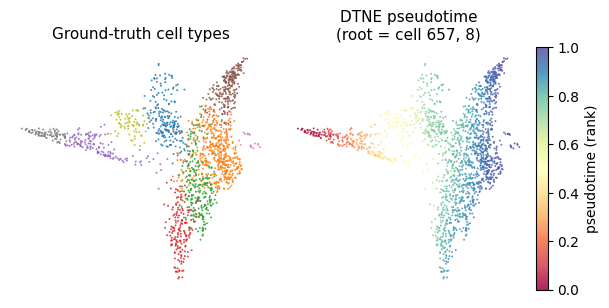


Pseudotime range: [0.000, 1.000]


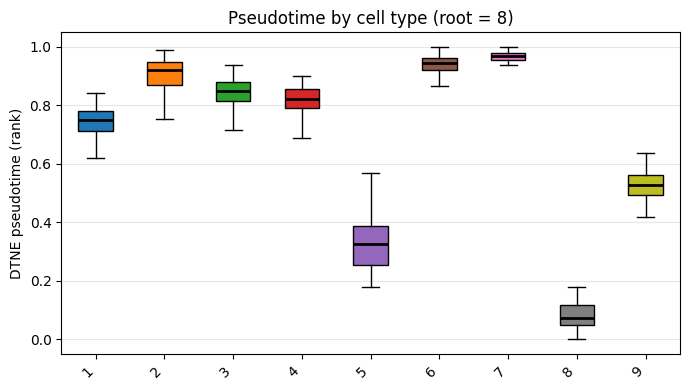

In [12]:
RUN_DTNE_DOWNSTREAM = True

if RUN_DTNE_DOWNSTREAM and "DTNE" in embeddings:
    pseudotime = plot_pseudotime_panels(
        methods["DTNE"], "DTNE",
        embeddings["DTNE"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types,
        order_method="order_cells",
        save_path=FIGURES_DIR / "nestorowa_dtne_pseudotime",
    )
    if pseudotime is not None:
        adata.obs["pseudotime_dtne"] = pseudotime
        print(f"\nPseudotime range: [{pseudotime.min():.3f}, {pseudotime.max():.3f}]")
        plot_pseudotime_boxplot(
            pseudotime, labels,
            adata.obs["cell_type"].cat.categories,   # cell_type, not nestorowa_clusters
            zip_types,
            method_name="DTNE",
            root_label=labels[ROOT_CELL_IDX],
            save_path=FIGURES_DIR / "dtne_nestorowa_pseudotime_by_type",
        )
elif RUN_DTNE_DOWNSTREAM:
    print("DTNE embedding not available — skipping downstream.")
else:
    print("Pseudotime skipped (set RUN_DTNE_DOWNSTREAM = True)")

In [13]:
from scipy.stats import spearmanr

if "pseudotime_entropath" in adata.obs and "pseudotime_dtne" in adata.obs:
    pt_ep = adata.obs["pseudotime_entropath"].values
    pt_dt = adata.obs["pseudotime_dtne"].values
    mask = ~(np.isnan(pt_ep) | np.isnan(pt_dt))
    rho_sp, _ = spearmanr(pt_ep[mask], pt_dt[mask])
    print(f"\nPseudotime Spearman (EntroPath vs DTNE): {rho_sp:.3f}")


Pseudotime Spearman (EntroPath vs DTNE): 0.962


In [14]:
ROOT = ROOT_CELL_IDX
geo = geodesic_from_root(X, ROOT, k_neighbors=20)

reachable = np.isfinite(geo)
n_unreachable = int((~reachable).sum())
if n_unreachable:
    print(f"WARNING: {n_unreachable}/{len(geo)} cells unreachable from root at k=20 "
          f"(graph fragmented); correlations computed on reachable cells only.\n")

# Each method's pseudotime. EntroPath/DTNE come from the downstream blocks above.
pseudotimes = {}
for name, key in [("EntroPath", "pseudotime_entropath"), ("DTNE", "pseudotime_dtne")]:
    if key in adata.obs:
        pseudotimes[name] = adata.obs[key].values
    else:
        print(f"[skip] {key} not in adata.obs — pseudotime not computed")

print(f"Geodesic-pseudotime correlation "
      f"(high-D input, k_neighbors=20, root cell {ROOT}, label={labels[ROOT]}):")
print(f"{'Method':<12s}  {'Pearson':>8s}  {'Spearman':>8s}  {'Kendall':>8s}")
print("-" * 44)
rows = []
for name, pt in pseudotimes.items():
    p, s, k = correlation_triple(geo, pt)
    print(f"{name:<12s}  {p:>8.3f}  {s:>8.3f}  {k:>8.3f}")
    rows.append({"Method": name, "Pearson": p, "Spearman": s, "Kendall": k})

df_geo = pd.DataFrame(rows).set_index("Method")
geo_path = RESULTS_DIR / "nestorowa_geodesic_pseudotime_corr.csv"
df_geo.to_csv(geo_path)
print(f"\nSaved to {geo_path.relative_to(PROJECT_ROOT)}")
print("\n=== LaTeX ===")
print(df_geo.round(3).to_latex(float_format="%.3f"))

Geodesic-pseudotime correlation (high-D input, k_neighbors=20, root cell 657, label=8):
Method         Pearson  Spearman   Kendall
--------------------------------------------
EntroPath        0.892     0.959     0.834
DTNE             0.973     0.969     0.859

Saved to results/nestorowa/nestorowa_geodesic_pseudotime_corr.csv

=== LaTeX ===
\begin{tabular}{lrrr}
\toprule
 & Pearson & Spearman & Kendall \\
Method &  &  &  \\
\midrule
EntroPath & 0.892 & 0.959 & 0.834 \\
DTNE & 0.973 & 0.969 & 0.859 \\
\bottomrule
\end{tabular}



In [15]:
n_disconnected = np.sum(~np.isfinite(geo))
if n_disconnected > 0:
    print(f"WARNING: {n_disconnected} cells unreachable from root. "
          f"Increase k_neighbors.")